In [1]:
import pandas as pd

df = pd.read_csv('RELIANCE.csv')
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [2]:
# How big is our dataset?
print("Rows and Columns:", df.shape)
print("Column names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Rows and Columns: (5306, 15)
Column names: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']

Data types:
Date                   object
Symbol                 object
Series                 object
Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume    float64
%Deliverble           float64
dtype: object


In [3]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\n")

# Basic statistics
print("Basic Statistics:")
df.describe()

Missing values in each column:
Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     514
%Deliverble            514
dtype: int64


Basic Statistics:


,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03,5.306000e+03,2.456000e+03,4.792000e+03,4792.000000
mean,1010.984866,1012.602375,1026.823803,996.886977,1011.157143,1011.316839,1011.937409,5.583028e+06,6.076715e+14,1.452306e+05,2.280885e+06,0.435039
std,570.987079,572.575893,581.986757,560.703328,570.938608,571.046753,571.222520,4.983793e+06,8.369739e+14,1.297557e+05,1.882665e+06,0.144722
min,203.200000,205.500000,219.500000,197.150000,203.300000,203.200000,212.290000,5.282000e+04,4.295543e+12,2.991000e+03,2.909700e+04,0.076300
25%,572.137500,572.925000,582.950000,564.237500,572.062500,572.512500,573.190000,2.836454e+06,2.203354e+14,7.215900e+04,1.194524e+06,0.323325
50%,937.950000,939.000000,950.075000,927.550000,939.025000,938.275000,939.785000,4.213432e+06,3.662999e+14,1.021435e+05,1.810434e+06,0.449450
75%,1247.387500,1247.675000,1267.350000,1227.450000,1248.287500,1248.275000,1247.375000,6.602604e+06,6.656490e+14,1.686702e+05,2.752935e+06,0.544300
max,3220.850000,3298.000000,3298.000000,3141.300000,3223.000000,3220.850000,3197.750000,6.523089e+07,1.473434e+16,1.428490e+06,3.495888e+07,0.978300


In [4]:
# Step 4 - Data Cleaning

# Fix 1: Convert Date from text to proper date format
df['Date'] = pd.to_datetime(df['Date'])

# Fix 2: Drop columns we don't need for analysis
df = df.drop(columns=['Symbol', 'Series', 'Last', 'Trades', 'Deliverable Volume', '%Deliverble'])

# Fix 3: Drop rows with any missing values
df = df.dropna()

# Fix 4: Reset the index
df = df.reset_index(drop=True)

# Check result
print("Cleaned data shape:", df.shape)
print("Missing values now:", df.isnull().sum().sum())
df.head()

Cleaned data shape: (5306, 9)
Missing values now: 0


,Date,Prev Close,Open,High,Low,Close,VWAP,Volume,Turnover
0,2000-01-03,233.05,237.50,251.70,237.50,251.70,249.37,4456424,1.111319e+14
1,2000-01-04,251.70,258.40,271.85,251.30,271.85,263.52,9487878,2.500222e+14
2,2000-01-05,271.85,256.65,287.90,256.65,282.50,274.79,26833684,7.373697e+14
3,2000-01-06,282.50,289.00,300.70,289.00,294.35,295.45,15682286,4.633254e+14
4,2000-01-07,294.35,295.00,317.90,293.00,314.55,308.91,19870977,6.138388e+14


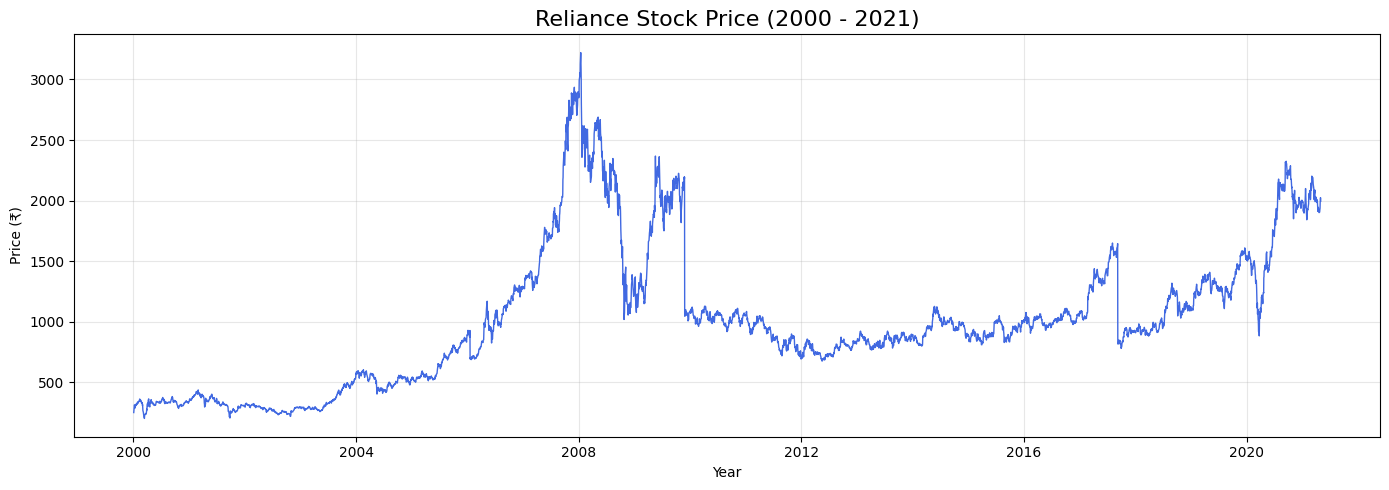

In [5]:
import matplotlib.pyplot as plt

# Chart 1 - Closing price over time
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], color='royalblue', linewidth=1)
plt.title('Reliance Stock Price (2000 - 2021)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (₹)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

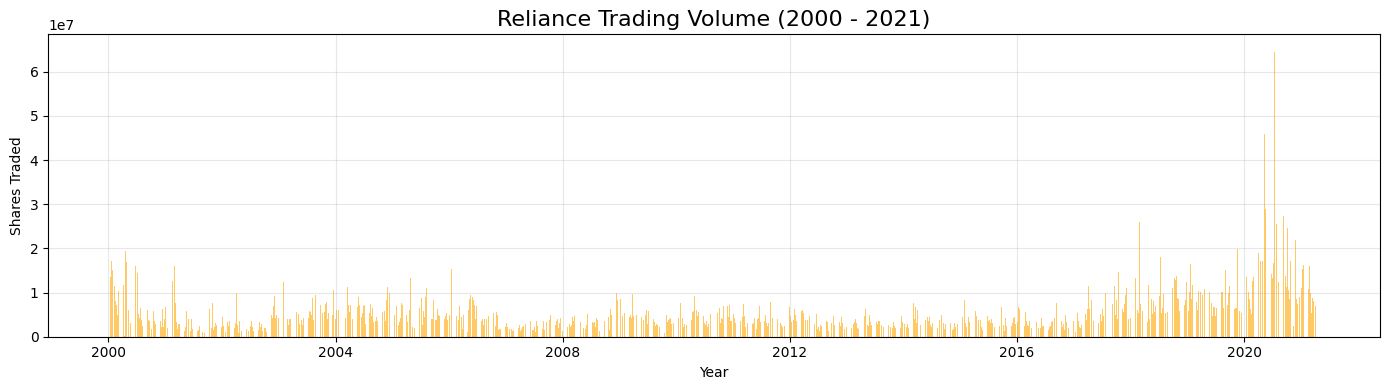

In [6]:
# Chart 2 - How much was traded each day?
plt.figure(figsize=(14, 4))
plt.bar(df['Date'], df['Volume'], color='orange', alpha=0.6)
plt.title('Reliance Trading Volume (2000 - 2021)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Shares Traded')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

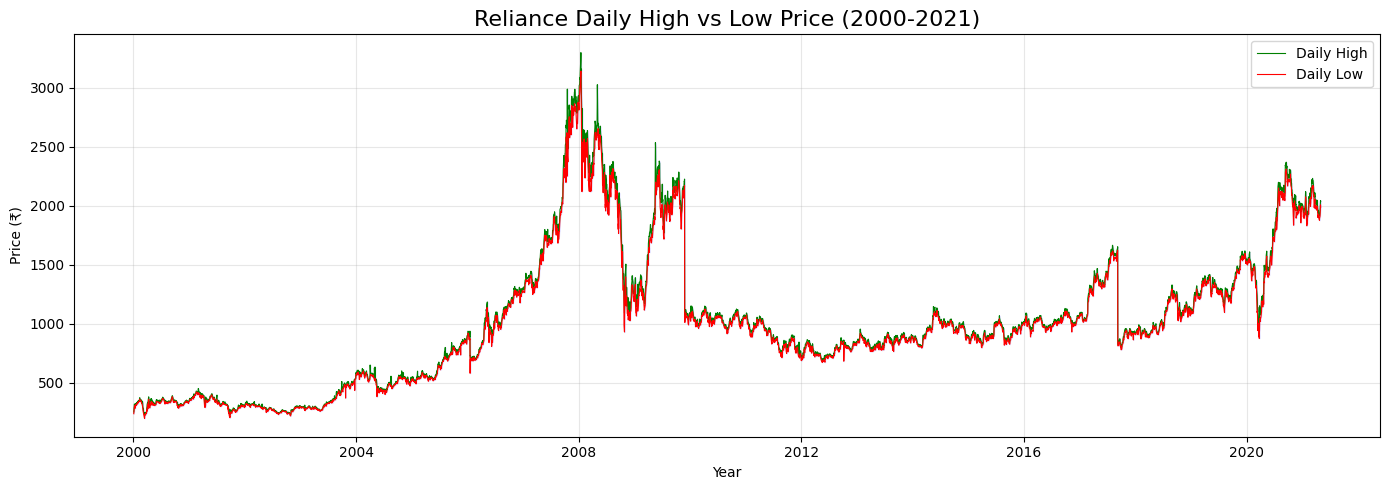

In [7]:
# Chart 3 - Daily High vs Low price
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['High'], color='green', linewidth=0.8, label='Daily High')
plt.plot(df['Date'], df['Low'], color='red', linewidth=0.8, label='Daily Low')
plt.fill_between(df['Date'], df['High'], df['Low'], alpha=0.1, color='blue')
plt.title('Reliance Daily High vs Low Price (2000-2021)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Create our features (what we use to predict)
df['Tomorrow'] = df['Close'].shift(-1)  # tomorrow's price
df = df.dropna()  # remove last row (no tomorrow for it)

X = df[['Open', 'High', 'Low', 'Volume']]  # input features
y = df['Tomorrow']                          # what we want to predict

# Split data - 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 4244
Testing rows: 1061


In [9]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Test the model
score = model.score(X_test, y_test)
print(f"Model Accuracy: {score * 100:.2f}%")

Model Accuracy: 99.42%


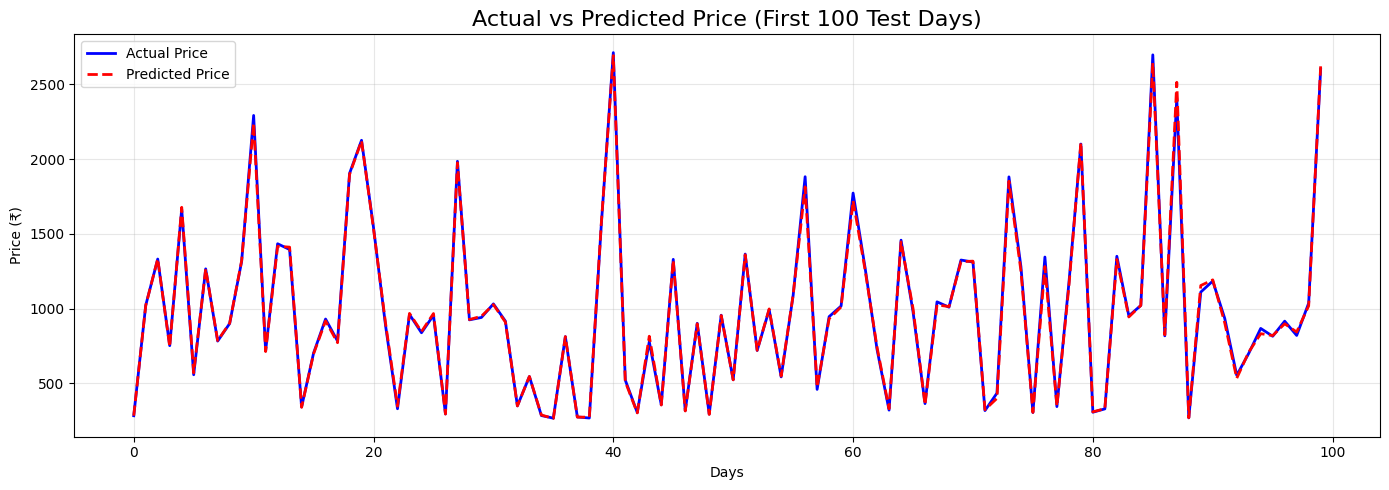

In [10]:
# Make predictions
predictions = model.predict(X_test)

# Show actual vs predicted
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:100], color='blue', label='Actual Price', linewidth=2)
plt.plot(predictions[:100], color='red', label='Predicted Price', 
         linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Price (First 100 Test Days)', fontsize=16)
plt.xlabel('Days')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()